dependencies


In [87]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import os
import numpy as np


#from IPython.display import HTML

all constants

In [88]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=40

Import data into tensorflow dataset object

We will use image_dataset_from_directory api to load all images in tensorflow dataset: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

In [89]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../end-to-end-breast-cancer-classification-using-cnn/dataset",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 780 files belonging to 3 classes.


In [90]:
class_names = dataset.class_names
class_names

['benign', 'malignant', 'normal']

In [91]:
len(dataset)
#25 it's the number of batchs 


25

In [92]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
#print(labels_batch.numpy()) show [0 0 0 0 1 0 0 1 0 0 2 1 1 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1] : 
# 0 , 1, 2 : ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy'] for 32 images in the batch


(32, 256, 256, 3)
[0 0 0 1 0 1 0 0 2 0 2 0 0 0 1 0 0 1 2 2 1 2 0 0 0 2 2 1 1 1 0 0]


2025-11-17 18:00:29.830830: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Visualize some of the images from our dataset

2025-11-17 18:00:29.936110: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


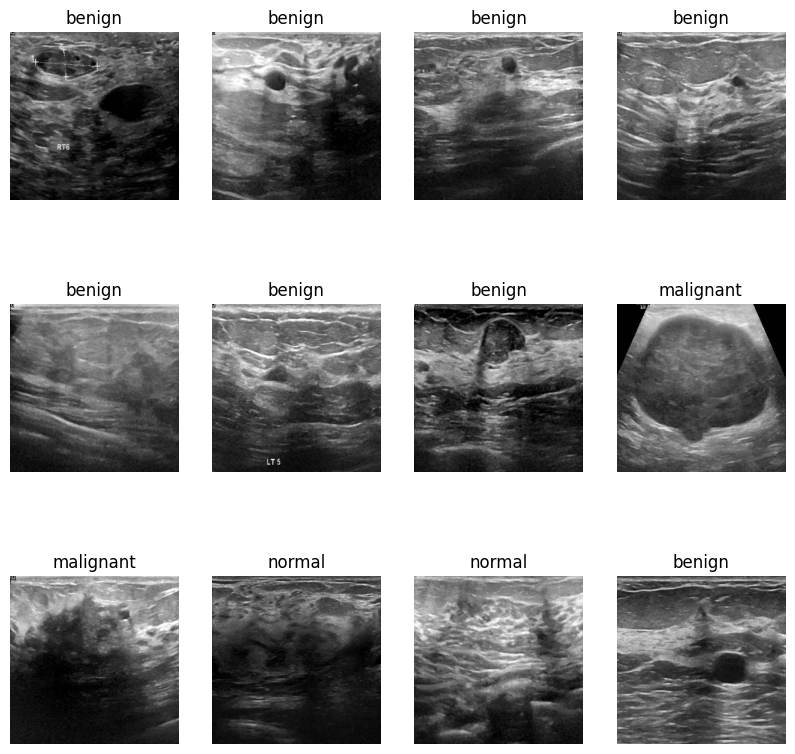

In [93]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

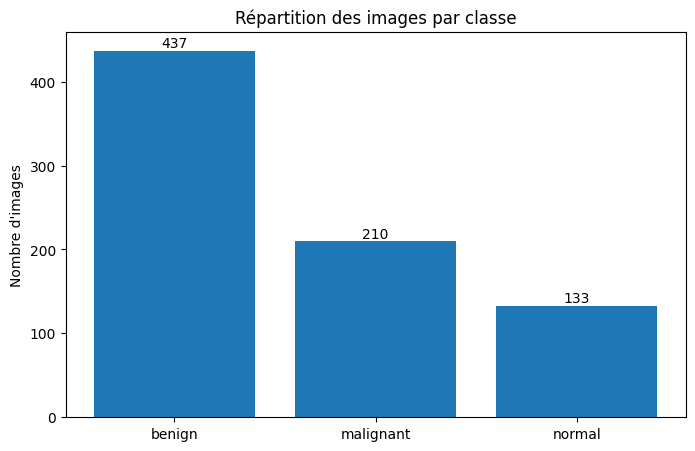

benign: 437 images
malignant: 210 images
normal: 133 images


In [94]:
import os
import matplotlib.pyplot as plt

base_dir = "../end-to-end-breast-cancer-classification-using-cnn/dataset"
classes = ["benign", "malignant", "normal"]

# fonction de comptage
def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".png", ".jpeg"))
    ])

# compter les images par classe
image_counts = []
for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    count = count_images(cls_path)
    image_counts.append(count)

# --- Affichage ---
plt.figure(figsize=(8, 5))
bars = plt.bar(classes, image_counts)

# Ajouter les valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylabel("Nombre d'images")
plt.title("Répartition des images par classe")
plt.show()

# Affichage console
for cls, count in zip(classes, image_counts):
    print(f"{cls}: {count} images")


data split

In [95]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    print("ds_size",ds_size)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    print("train_size",train_size)
    #80% so train_size= 54
    val_size = int(val_split * ds_size)
    #10% so train_size= 6
    print("val_size",val_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    #take the rest , which is 8
    test_ds = ds.skip(train_size).skip(val_size)
    print("train_ds: ",len(train_ds), " val_ds: ",len(val_ds)," test_ds: ",len(test_ds))
    
    return train_ds, val_ds, test_ds

In [96]:
train_ds, val_ds, test_ds=get_dataset_partitions_tf(dataset)

ds_size 25
train_size 20
val_size 2
train_ds:  20  val_ds:  2  test_ds:  3


improve the performance of training

In [97]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

building model

Creating a Layer for Resizing and Normalization
Before we feed our images to network, we should be resizing it to the desired size. Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256). This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.

In [98]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255),
])

Data augmentation

In [99]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
])

In [100]:
#apply data augmentation to train dataset
#train_ds = train_ds.map(
#    lambda x, y: (data_augmentation(x, training=True), y)
#).prefetch(buffer_size=tf.data.AUTOTUNE)

build model

In [101]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    resize_and_rescale,
    #data_augmentation,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

/Users/ikram/miniconda3/envs/tf-arm/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

compile the model

In [103]:
#We use adam Optimizer, SparseCategoricalCrossentropy for losses, accuracy as a metric
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [104]:
#"steps_per_epoch    = train_generator.samples // BATCH_SIZE
#validation_steps   = validation_generator.samples // BATCH_SIZE

history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS,
    #steps_per_epoch=steps_per_epoch,
    #validation_steps=validation_steps,
)

Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 709ms/step - accuracy: 0.5645 - loss: 0.9946 - val_accuracy: 0.6406 - val_loss: 0.8950
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 655ms/step - accuracy: 0.5806 - loss: 0.9422 - val_accuracy: 0.6562 - val_loss: 0.8057
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 643ms/step - accuracy: 0.6113 - loss: 0.8666 - val_accuracy: 0.6719 - val_loss: 0.7773
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 640ms/step - accuracy: 0.6371 - loss: 0.8208 - val_accuracy: 0.7500 - val_loss: 0.7375
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 688ms/step - accuracy: 0.6661 - loss: 0.7711 - val_accuracy: 0.7188 - val_loss: 0.6765
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 637ms/step - accuracy: 0.6774 - loss: 0.7256 - val_accuracy: 0.7188 - val_loss: 0.6591
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 638ms/step - accuracy: 0.7129 - loss: 0.6424 - val_accuracy: 0.7812 - val_loss: 0.5788
Epoch 8/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 629ms/step - accuracy: 0.7435 - loss: 0.5822 - val_accu

In [105]:
scores = model.evaluate(test_ds)
print(scores)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.9479 - loss: 0.3227
[0.3227176368236542, 0.9479166865348816]


visualize data 

In [106]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

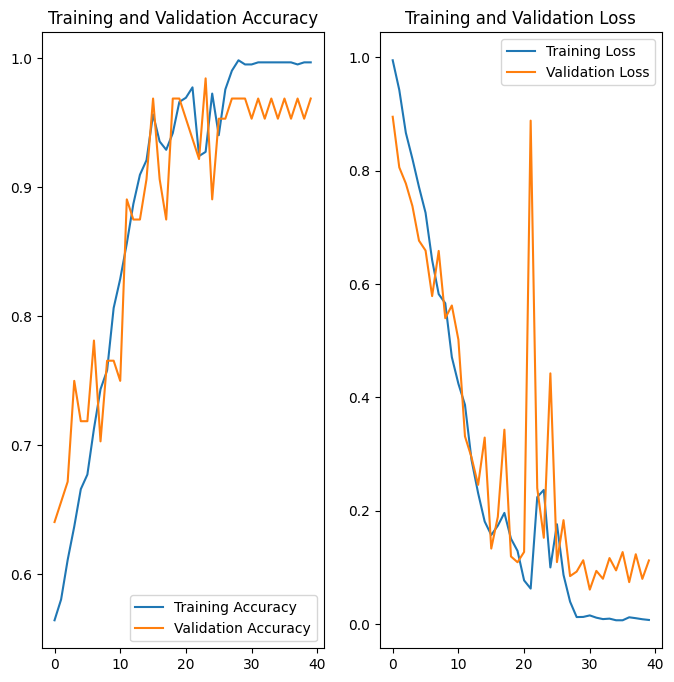

In [113]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
# 🔥 Save the figure
plt.savefig("training_validation_plot.png", dpi=300, bbox_inches='tight')

plt.show()

Run prediction on a sample image

first image to predict
actual label: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
predicted label: benign


2025-11-17 18:08:59.066792: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


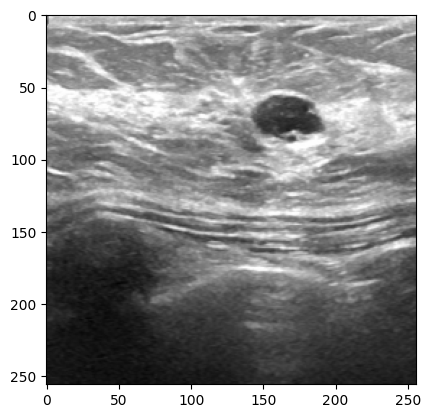

In [108]:
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

Write a function for inference

In [109]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


2025-11-17 18:08:59.628990: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


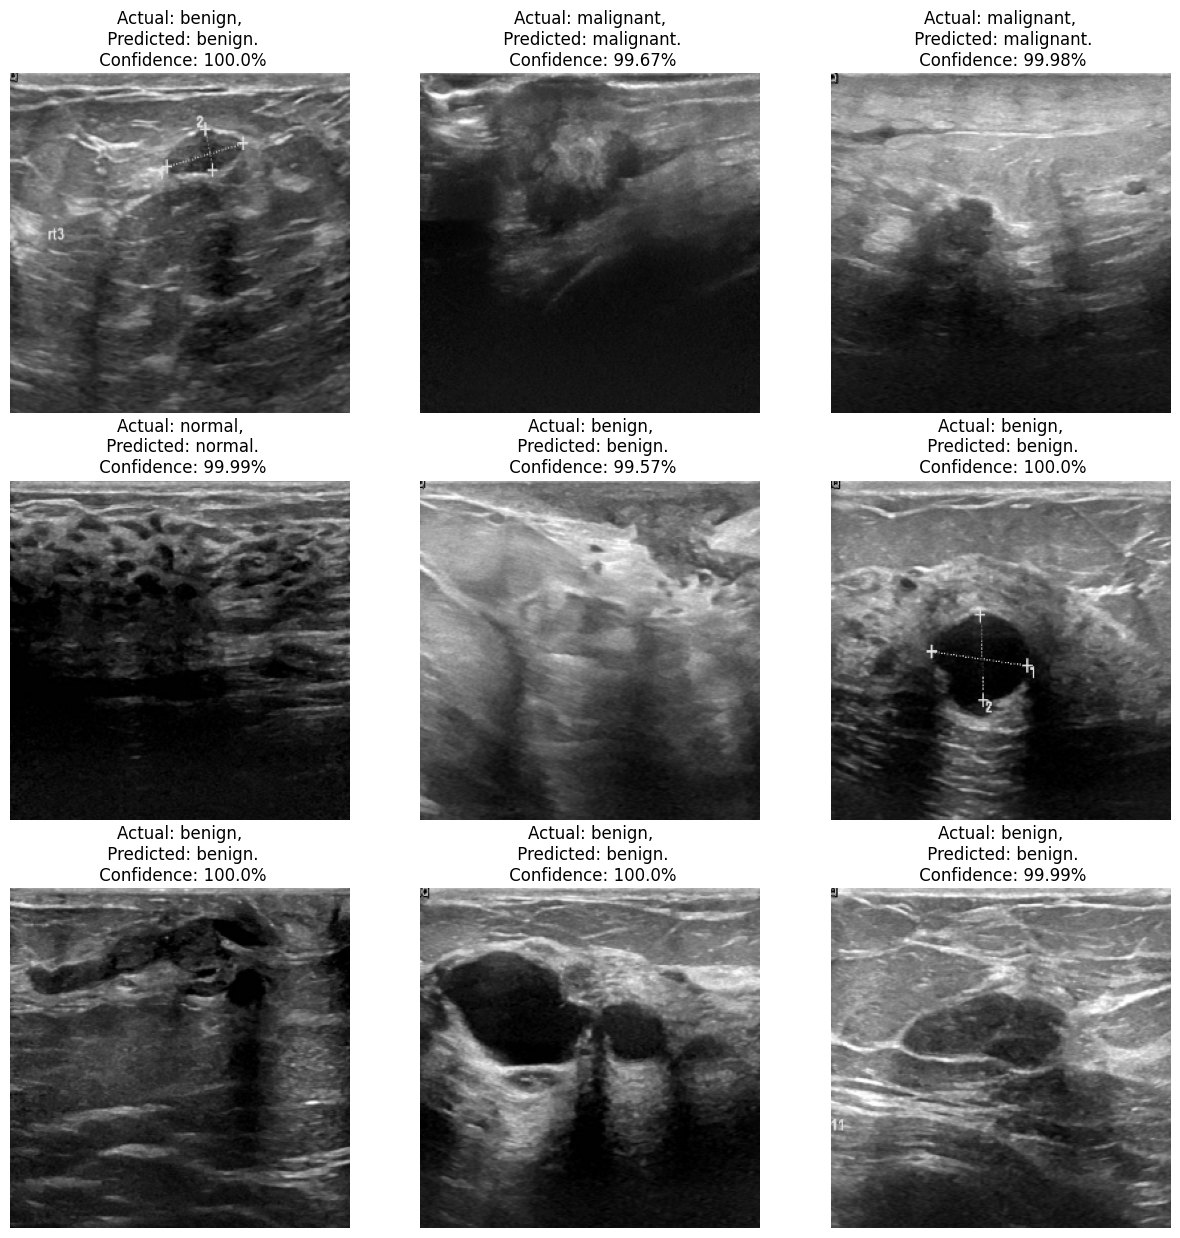

In [110]:
#Now run inference on few sample images
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

Saving the Model

In [111]:
#pour voir le chemin courant 
print(os.getcwd())

/Users/ikram/Desktop/github-project/end-to-end-breast-cancer-classification-using-cnn


In [114]:
import os
import re

models_dir = "../end-to-end-breast-cancer-classification-using-cnn/models"
os.makedirs(models_dir, exist_ok=True)

# Expression régulière pour extraire la version
pattern = r"predict_breast_cancer_version(\d+)\.h5"

existing_versions = []
for name in os.listdir(models_dir):
    match = re.match(pattern, name)
    if match:
        existing_versions.append(int(match.group(1)))

model_version = max(existing_versions + [0]) + 1

save_path = os.path.join(models_dir, f"predict_breast_cancer_version{model_version}.h5")
model.save(save_path)

print(f"✅ Modèle sauvegardé dans : {os.path.abspath(save_path)}")


✅ Modèle sauvegardé dans : /Users/ikram/Desktop/github-project/end-to-end-breast-cancer-classification-using-cnn/models/predict_breast_cancer_version2.h5
